# Poseidon (scOT): a guided walkthrough - solutions

Poseidon is a foundation model for PDEs (scOT) aimed towards solving fluid dynamics problems. In this investigation we will primarily focus on its behaviour when dealing with Compressed-Euler problems, as well as some more general properties.

| # | Section | What you measure |
|---|---------|------------------|
| 1 | Set-up | - |
| 2 | One model, several PDEs | How the same weights handle different PDE's, variables and timehorizons |
| 3 | Direct vs autoregressive | Whether one big jump beats many consequent small jumps when making a prediction |
| 4 | Spectral bias over time | The nature of Poseidon's failures and how they evolve over time |
| 5 | Out of distribution | What happens when the input drifts away from the training data |
| 6 | Resolution invariance | Whether a neural operator really is resolution-free |

# 1. Set-up

Four cells. Run them once, in order, top to bottom.

| Section| What is in it | Importance to you |
|---|---|---|
| **1.1** | imports, paths, the model | Not important - just run it |
| **1.2** | the dataset table and the settings you may want to change | Relatively important - try to understand key elements |
| **1.3** | the five key functions for fetching necessary data  | Very important - these functions are re-used everywhere |
| **1.4** | converting between physical and model units | Only useful for section 5 |

## 1.1 Environment, paths and the model

Boilerplate. Imports everything, loads the weights to disk etc. May take a while to run while the weights load.

In [ ]:
import os
os.environ["PYTORCH_ENABLE_MPS_FALLBACK"] = "1"

import sys

#every path below is relative to the folder this notebook sits in, so the
#whole folder can be moved or renamed without editing anything
ROOT = os.path.abspath("")
WEIGHTS = os.path.join(ROOT, "weights", "Poseidon-L")

#scOT and finitevolume_python ship inside this folder rather than being
#installed, so the folder itself has to be importable
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)

#a clear message here beats an ImportError on the next line
assert os.path.isdir(os.path.join(ROOT, "scOT")), (
    f"no scOT package in {ROOT} - open this notebook from inside the "
    "submission folder"
)

import numpy as np
import torch
import matplotlib.pyplot as plt
from scOT.model import ScOT
from scOT.problems.fluids.compressible import Gaussians, KelvinHelmholtz
from scOT.problems.fluids.incompressible import ShearLayer
from scOT.problems.fluids.normalization_constants import CONSTANTS


#--- the weights and the data -------------------------------------------------
#
#About 17 GB in total, so this is the slow cell. It downloads only what is
#missing, which makes it a no-op on a machine that already has the files and a
#safe thing to re-run after a Colab session drops.
#
#scOT hardcodes the filename it opens for each dataset, so each shard is
#renamed on the way in - NS-SL in particular ships as velocity_0.nc.

#one shard per dataset is enough: we only ever read the held-out test split
SHARDS = {
    "CE-KH":    ("camlab-ethz/CE-KH",    "data_0.nc",     "CE-KH.nc"),
    "CE-Gauss": ("camlab-ethz/CE-Gauss", "data_0.nc",     "CE-Gauss.nc"),
    "NS-SL":    ("camlab-ethz/NS-SL",    "velocity_0.nc", "NS-SL.nc"),
}


def fetch_everything():
    """
    Download the weights and one shard per dataset, skipping whatever is there.

    RETURNS:
        None. Files land under weights/ and data/ inside this folder
    """
    #the classic CDN path. On some machines the Xet backend crawls at ~10 kB/s
    #while this one runs at 10-40 MB/s
    os.environ.setdefault("HF_HUB_DISABLE_XET", "1")
    from huggingface_hub import hf_hub_download, snapshot_download

    #2.5 GB of weights, config included
    if not os.path.exists(os.path.join(WEIGHTS, "model.safetensors")):
        print("downloading Poseidon-L (2.5 GB) ...")
        snapshot_download("camlab-ethz/Poseidon-L", local_dir=WEIGHTS,
                          allow_patterns=["config.json", "model.safetensors"])

    #about 4.8 GB each
    for key, (repo, remote_name, local_name) in SHARDS.items():
        folder = os.path.join(ROOT, "data", key)
        target = os.path.join(folder, local_name)

        if os.path.exists(target):
            continue

        print(f"downloading {key} (4.8 GB) ...")
        downloaded = hf_hub_download(repo, remote_name, repo_type="dataset",
                                     local_dir=folder)

        #scOT opens this exact name, so rename the shard once it has landed
        os.replace(downloaded, target)

    print("weights and data ready")


fetch_everything()

#the fastest backend this machine has
device = ("mps" if torch.backends.mps.is_available()
          else "cuda" if torch.cuda.is_available()
          else "cpu")


#load the weights to device
model = ScOT.from_pretrained(WEIGHTS).to(device)

## 1.2 The datasets and the settings

Three datasets based on two sets of PDEs. `CE-KH` and `CE-Gauss` are compressible Euler; `NS-SL` is incompressible Navier-Stokes. This section effectively sets up the necessary datasets so data can later be extracted from them.

Please note the values of 'Horizon' and 'Panel Channel'. These are default values that many of the functions in this notebook will reference (many functions will have optional arguments e.g., horizon=Horizon). Be aware of this - these values hold no significant value and are just defaults. You may change them, and may also change the individual inputs to functions by using these optional arguments. When experimenting with the functions and graphs yourself, it is recommended to set these optional arguments to something else (e.g., horizon=20) to see how the result/graphs will change, but it is not necessary.

In [ ]:


#the four channels Poseidon works in, in order. Every dataset below arrives in this layout
CHANNEL_NAMES = ["density (rho)", "x-velocity (u)", "y-velocity (v)", "pressure (p)"]

#essentially the max time horizon of the model. For Poseidon it's 20 frames
#frames and how time works for Poseidon is explained later
TIME_NORM = CONSTANTS["time"]


#our datasets
DATASETS = {
    "CE-KH": dict(
        reader=KelvinHelmholtz,
        path=os.path.join(ROOT, "data", "CE-KH"),
        title="compressible Euler, Kelvin-Helmholtz",
        pde="nonlinear hyperbolic conservation law"),

    "CE-Gauss": dict(
        reader=Gaussians,
        path=os.path.join(ROOT, "data", "CE-Gauss"),
        title="compressible Euler, Gaussian vortices",
        pde="nonlinear hyperbolic conservation law"),

    "NS-SL": dict(
        reader=ShearLayer,
        path=os.path.join(ROOT, "data", "NS-SL"),
        title="incompressible Navier-Stokes, shear layer",
        pde="parabolic, with an elliptic pressure constraint"),
}

#Datasets that section 2 uses
ACTIVE_DATASETS = ["CE-KH", "CE-Gauss", "NS-SL"]

#the one sections 3 to 6 run on. Do not change this. 
DATASET = "CE-Gauss"

#how many frames ahead to predict, wherever a section does not sweep the
#horizon itself. Used by 2.1, 4.2, section 5 and section 6. Anything up to 20
HORIZON = 10

#the channel those comparisons draw.
PANEL_CHANNEL = 1

## 1.3 Getting data and making predictions

**This is the section worth reading.** Five functions, and between them they are every call the rest of the notebook makes.

A single dataset from Poseidon contains thousands of training trajectories, hundreds of evaluation trajectories, and only 240 test trajectories. The goal of this section is to provide you with tools to extract the necessary information from a single one of these trajectories. 

| function | what it gives you |
|---|---|
| `load_window(horizon)` | loads a single dataset with 240 held-out trajectories, each paired t=0 --> t=T |
| `get_sample(horizon, index)` | fetch data of a single trajectory from the larger dataset |
| `predict(model, sample, device)` | have Poseidon make a prediction given an input field |
| `get_all_data(...)` | Gathers all the actually important data. Outputs: initial field, truth at t=T, Poseidon's prediction at t=T, Error |
| `relative_error(truth, prediction)` | how far the forecast landed from the truth |

A `sample` is a dictionary in scOT's own terminology. `"pixel_values"` is the input field at t=0, `"labels"` the true field at the horizon, and `"time"` the horizon time. First have shape `[4, 128, 128]` and `"time"`, which is a float.

Each function here builds on top of one another, so please understand how they are used together. 

1. load_window() loads up one full dataset
2. get_sample() builds on top of load_window() - it fetches one single trajectory from the larger dataset (input field + time)
3. predict() builds on top of sample(). It takes in a single trajectory, and has Poseidon make a prediction (since time is an input)
4. get_all_data() builds on top of predict(). It returns 4 individual pieces of data you most care about: the initial field, the final (true) field, Poseidon's predicted field and the error between the latter two. 
5. relative_error() is complementary and should be self explanatory 


In [184]:
def load_window(final_time, dataset_key=DATASET):
    """
    Fetch the dataset with 240 test trajectories. 

    ARGS:
        final_time (int): how many frames ahead to predict, at most 20
        dataset_key (str): which entry of DATASETS to read

    RETURNS:
        dataset (torch Dataset): 240 items, one per held-out trajectory
    """
    spec = DATASETS[dataset_key]

    #load the necessary dataset
    dataset = spec["reader"](which="test", #test trajectory
                             num_trajectories=1, #exists because scOT requires it. Not actually relevant to the test data
                             data_path=spec["path"], #specify the link
                             max_num_time_steps=1, 
                             time_step_size=final_time, #how many frames into the future we want to look
                             fix_input_to_time_step=0) #this asks for the starting point, for us its always frame 0

    #find the maximum number of trajectories that the dataset has
    dataset.N_max = dataset.reader["sample"].shape[0]
    dataset.post_init()

    #return the dataset which now has data ready for extraction
    return dataset


def get_sample(horizon, index=0, dataset_key=DATASET):
    """
    Fetch one held-out trajectory from the bigger dataset.

    ARGS:
        horizon (int): how many frames ahead to predict, at most 20
        index (int): which of the 240 held-out trajectories to take
        dataset_key (str): which entry of DATASETS to read

    RETURNS:
        sample (dict): "pixel_values" the input field at t=0 [4, 128, 128],
                       "labels" the true field at the horizon [4, 128, 128],
                       "time" the lead time rescaled into [0, 1]
    """

    dataset = load_window(horizon, dataset_key)
    sample = dataset[index]

    return sample


def predict(model, sample, device):
    """
    Run one forward pass: one input field in, one predicted field out.

    ARGS:
        model (ScOT): the loaded Poseidon-L model
        sample (dict): needs "pixel_values", the input field [4, H, W], and
                       "time", the lead time as a float in [0, 1]
        device (str): "mps", "cuda" or "cpu", wherever the weights live

    RETURNS:
        prediction (tensor): the forecast field [4, H, W], back on the CPU
    """
    #move the input field to the GPU
    x = sample["pixel_values"].unsqueeze(0).to(device)

    #t is how far into the future we want to predict. However, within sample it is a float. We need it as a tensor
    t = torch.tensor([sample["time"]]).to(device)

    #no_grad because inference never learns
    with torch.no_grad():
        return model(pixel_values=x, time=t).output[0].cpu()


def get_all_data(model, device, horizon, index=0, dataset_key=DATASET):
    """
    Retrieve all the most important information from one forward pass.

    ARGS:
        model (ScOT): the loaded Poseidon-L model
        device (str): wherever the weights live
        horizon (int): how many frames ahead to predict, at most 20
        index (int): which of the 240 held-out trajectories to take
        dataset_key (str): which entry of DATASETS to read

    RETURNS:
        input_field (tensor): the input at t=0 [4, H, W]
        truth (tensor): the true field at t=horizon [4, H, W]
        prediction (tensor): Poseidon's forecast for the same [4, H, W]
        time (float): the lead time as the model sees it, in [0, 1]
    """

    #get the sample data
    sample = get_sample(horizon, index, dataset_key)

    #disect the sample to get all the individually important pieces of data
    return sample["pixel_values"], sample["labels"], predict(model, sample, device), sample["time"]


def relative_error(truth, prediction):
    """
    Relative error between two fields.

    ARGS:
        truth (tensor): the true field [4, H, W]
        prediction (tensor): the forecast for that same field [4, H, W]

    RETURNS:
        error (tensor): the relative L1 error, a single scalar
    """
    return (prediction - truth).abs().sum() / truth.abs().sum()

## 1.4 Physical units and model units

This is a supporting section that does not become important until you reach section 5. Poseidon does not operate in any physical units, so we need a way to transition between said physical units and Poseidon's own arbitrary values. This section provides this method.

In [167]:
#normalise between model and physical units. This is only relevant to section 5
MEAN = CONSTANTS["mean"]
STD = CONSTANTS["std"]
MEAN_PRESSURE = getattr(load_window(1), "mean_pressure", 0.0)


def denormalise(field):
    """
    Model units -> physical units, undoing scOT's own conversion.

    ARGS:
        field (tensor): a field as the model sees it [4, H, W]

    RETURNS:
        raw (tensor): the same field in physical units [4, H, W]
    """
    #reverse of scOT's process
    raw = field * STD + MEAN
    raw[3] = raw[3] + MEAN_PRESSURE

    return raw


def normalise(field):
    """
    Physical units -> model units, the exact inverse of denormalise().

    ARGS:
        field (array): a field in physical units [4, H, W]

    RETURNS:
        x (tensor): the same field in model units [4, H, W]
    """
    #conversion is necessary because mean and std are tensors
    x = torch.tensor(field, dtype=torch.float32)

    #scOT's process, in scOT's order. The pressure offset is a physical-unit
    #number, so it has to come off BEFORE the shared scaling - doing it after
    #divides it by STD[3] and feeds Poseidon a pressure channel near +11
    x[3] = x[3] - MEAN_PRESSURE
    x = (x - MEAN) / STD

    return x

# 2. One model, several PDEs

Poseidon was pretrained on a range of PDEs, and the purpose of this section is to demonstrate this. Poseidon is claimed to be a foundational model, and its ability to generalise across many classes of PDEs is very important to this claim. 

| key | equation | class |
|-----|----------|-------|
| `CE-KH` | compressible Euler | nonlinear hyperbolic conservation law |
| `CE-Gauss` | compressible Euler | nonlinear hyperbolic conservation law |
| `NS-SL` | incompressible Navier-Stokes | parabolic, with an elliptic pressure constraint |

Please note that beyond Section 2 the notebook will only focus on the *CE-Gauss* dataset, thus working with only one set of PDEs. 

## 2.1 Plotting Truth Against Poseidon's Prediction

Below is a simple function that draws a 4-figure panel of the input field, truth at t=T, Poseidon's prediction at t=T, and the error map.

In [ ]:
def truth_vs_prediction(input_field, true_field, prediction, horizon,
                        channel=PANEL_CHANNEL):
    """
    Draw the four-panel input, prediction, truth and difference comparison.

    ARGS:
        input_field (tensor): the input at t=0 [4, H, W]
        true_field (tensor): the true field at the horizon [4, H, W]
        prediction (tensor): the forecast for that same field [4, H, W]
        horizon (int): the lead time in frames, for the panel titles
        channel (int): which of the four channels to draw

    RETURNS:
        fig (Figure): the four-panel figure
    """
    #the error map: truth minus prediction, per pixel
    difference = true_field - prediction

    fig, axes = plt.subplots(1, 4, figsize=(18, 4.5))

    #image 1: initial state
    image1 = axes[0].imshow(input_field[channel].numpy(), cmap="viridis")
    axes[0].set_title("initial (t=0)")
    fig.colorbar(image1, ax=axes[0])

    #image 2: prediction
    image2 = axes[1].imshow(prediction[channel].numpy(), cmap="viridis")
    axes[1].set_title(f"prediction (t={horizon})")
    fig.colorbar(image2, ax=axes[1])

    #image 3: truth
    image3 = axes[2].imshow(true_field[channel].numpy(), cmap="viridis")
    axes[2].set_title(f"truth (t={horizon})")
    fig.colorbar(image3, ax=axes[2])

    #image 4: error map
    image4 = axes[3].imshow(difference[channel].numpy(), cmap="coolwarm")
    axes[3].set_title("difference")
    fig.colorbar(image4, ax=axes[3])

    #name the channel, so a rerun with a different one is self-labelling
    fig.suptitle(CHANNEL_NAMES[channel])

    fig.tight_layout()

    return fig


## Task 1

Play around the with the channels and time horizons to get a better feel for how Poseidon works. Note: The incompressible datasets carry a constant density and no pressure, so channels 0 and 3 are flat images for NS-SL.

## Question

What do you notice about Poseidon's mistakes? What detail does it typically fail to predict?



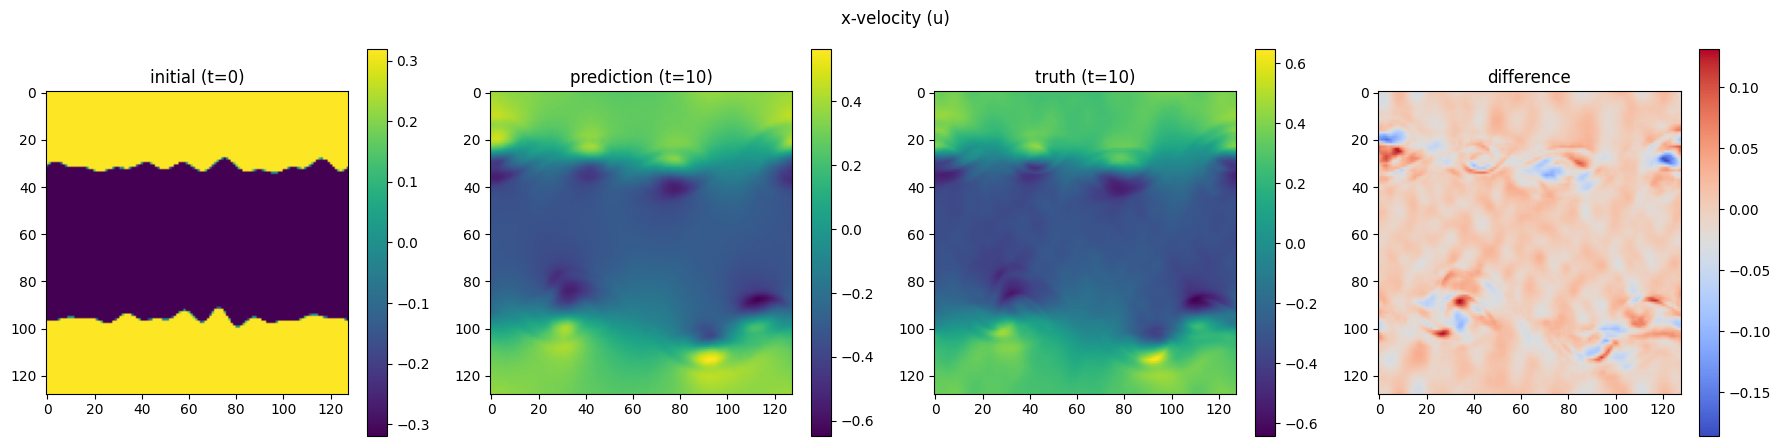

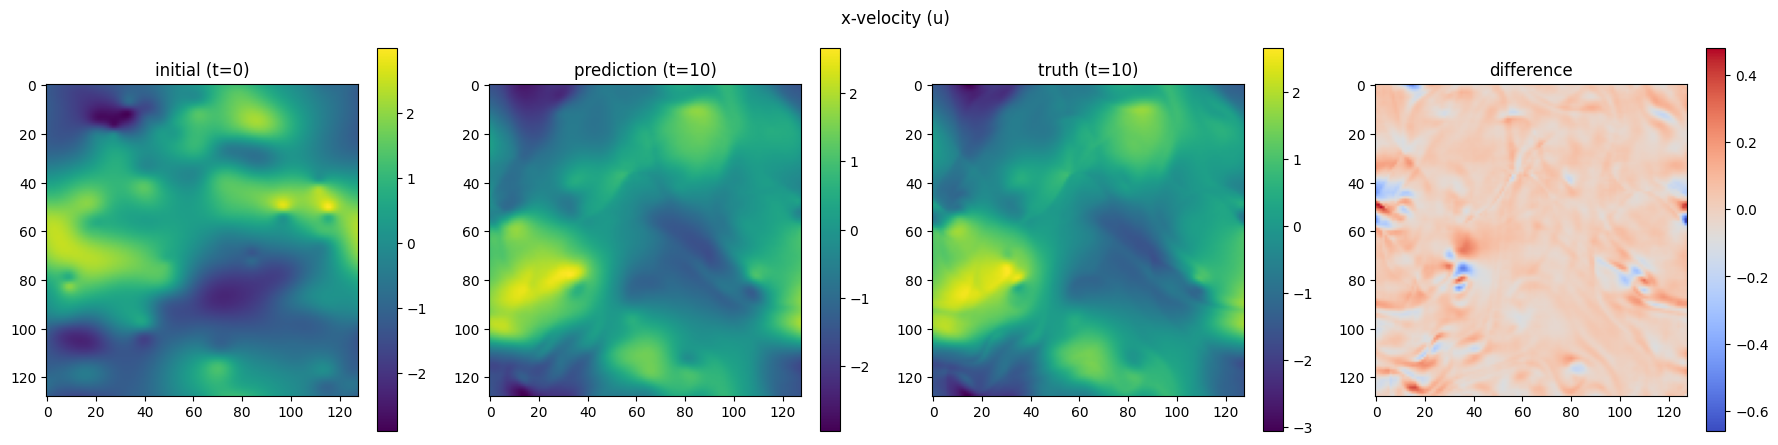

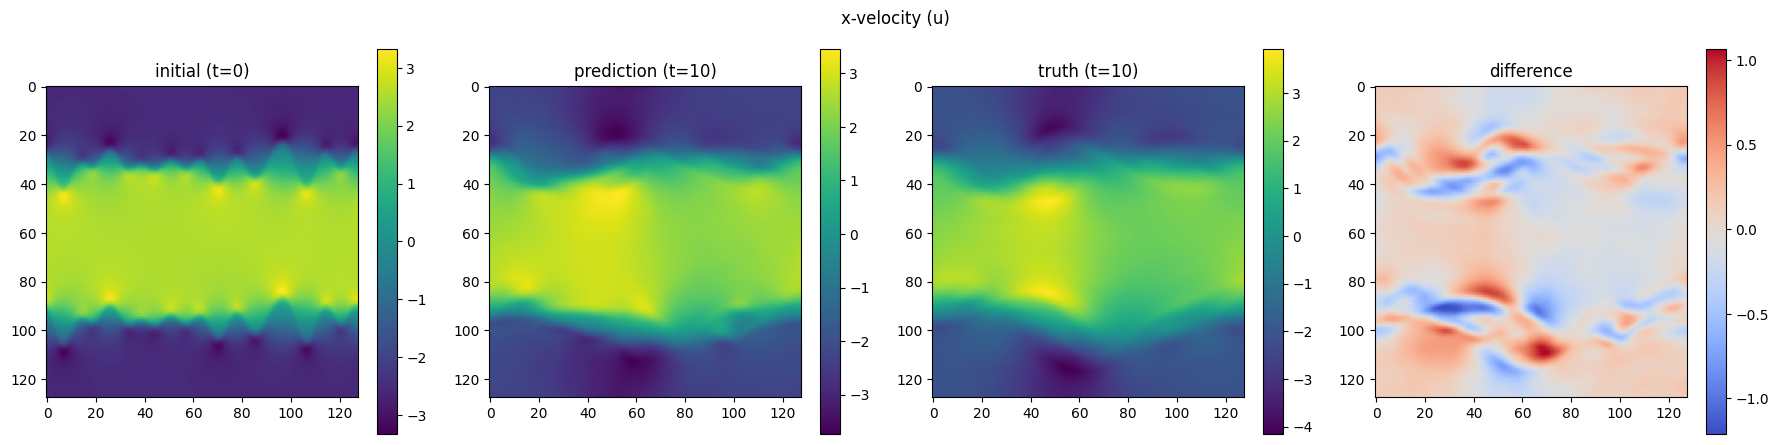

In [ ]:
#HORIZON is set in 1.2, because sections 4, 5 and 6 read it too. Change it
#there to move every figure in the notebook at once

#0 density, 1 x-velocity, 2 y-velocity, 3 pressure
CHANNEL = PANEL_CHANNEL   

#NS-SL is incompressible, so it carries a constant density and no pressure 
for key in ACTIVE_DATASETS:

    #one call gives the input, the truth and the forecast for this dataset
    input_field, truth, prediction, _ = get_all_data(model, device, HORIZON, dataset_key=key)

    #make the plot
    fig = truth_vs_prediction(input_field, truth, prediction, HORIZON, channel=CHANNEL)

    plt.show()


# 3. Direct vs autoregressive

Poseidon can jump from $t=0$ straight to any horizon $T$ in a single forward pass. That is a direct prediction. It can also be run autoregressively: take a small jump $\Delta t$, feed the output back in as the next input, and repeat $n$ times to reach $T = n\,\Delta t$.

$$
\hat u_{\text{direct}}(T) = f_\theta(u_0, T)
\qquad\text{vs.}\qquad
\hat u_{\text{auto}}(n\Delta t) = \underbrace{f_\theta(\,\cdots f_\theta(f_\theta(u_0,\Delta t),\Delta t)\cdots,\Delta t)}_{n\text{ applications}}
$$

Both reach the same horizon. From the second hop onwards the rollout method makes predictions based off its own imperfect output rather than on a true field, so each hop's error can build on the last one's. Direct prediction never has that problem, but it has to predict a much harder time jump.

Important note - keep the hop size `final_time / n_steps` even. The model only ever saw even lead times in training, so odd hop sizes can cause anomalous behaviour. For example, predicting a horizon of 12 through 4 hops of 3 frames can cause irregular error behaviour.

## 3.1 Implementing the two strategies

## Question

Which error would you expect to be greater and why?

## Task 2

Code the ending of rollout(). You are provided with additional functions in order to see how rollout() works in context with the rest of the code. Looking ahead at 3.2 may also help a bit. 

In [ ]:
def rollout(model, input_field, time_per_step, n_steps, device):
    """
    Roll the model forward in time by feeding its own input back in. 
    Make a desired number of predictions.

    ARGS:
        model (ScOT): the loaded Poseidon-L model
        input_field (tensor): the field at t=0, [4, H, W]
        time_per_step (float): the normalised lead time of ONE hop
        n_steps (int): how many hops to take
        device (str): wherever the weights live

    RETURNS:
        preds (list): n_steps tensors, each [4, H, W]. preds[i] is the
                      prediction after (i + 1) hops
    """
    #predictions
    preds = []

    #start from the t=0 field
    current = input_field

    #-----------------
    
    for _ in range(n_steps):

        #one forward pass
        sample = {"pixel_values": current, "time": time_per_step}
        pred = predict(model, sample, device)
        preds.append(pred)

        #feed it back in: output -> next input
        current = pred
    
    #-----------------

    return preds


def error_direct(model, device, final_time, n_steps):
    """
    Error of a single direct jump to each intermediate horizon.

    ARGS:
        model (ScOT): the loaded Poseidon-L model
        device (str): wherever the weights live
        final_time (int): the last horizon reached, in frames
        n_steps (int): how many horizons to split that into

    RETURNS:
        horizons (list): the lead times reached, in frames
        errors (list): the relative L1 error at each one
    """
    #check that final time divides evenly by the number of steps
    #(important because time is measured in frames)
    if final_time % n_steps != 0:
        raise ValueError("final time must divide evenly by the number of steps")

    #number of frames in one step
    step = final_time // n_steps

    #the model only ever saw even lead times during training
    if step % 2 != 0:
        raise ValueError("hop size must be even")

    #establish the horizons
    horizons = [(i + 1) * step for i in range(n_steps)]

    errors = []

    #make a direct prediction for every given horizon
    for horizon in horizons:

        #one read, then just the two fields the error needs
        sample = get_sample(horizon)
        truth = sample["labels"]
        prediction = predict(model, sample, device)

        #error calculation
        errors.append(relative_error(truth, prediction).item())

    return horizons, errors


def error_autoregressive(model, device, final_time, n_steps):
    """
    Error after each hop of an n_steps rollout.

    ARGS:
        model (ScOT): the loaded Poseidon-L model
        device (str): wherever the weights live
        final_time (int): the last horizon reached, in frames
        n_steps (int): how many hops to reach it in

    RETURNS:
        horizons (list): the lead times reached, in frames
        errors (list): the relative L1 error at each one
    """
    #check that final time divides evenly by the number of steps
    #(important because time is measured in frames)
    if final_time % n_steps != 0:
        raise ValueError("final time must divide evenly by the number of steps")

    #number of frames in one step. Has to be an integer
    step = final_time // n_steps

    #the model only ever saw even lead times during training
    if step % 2 != 0:
        raise ValueError("hop size must be even")

    #start field when t = 0
    sample_t0 = load_window(final_time)[0]["pixel_values"]

    #normalise the lead time to a format the model understands
    #(e.g., step 2 out of 20 --> 0.1)
    time_per_step = load_window(step)[0]["time"]

    #perform the autoregressive loop
    preds = rollout(model, sample_t0, time_per_step, n_steps, device)

    horizons, errors = [], []


    for i in range(n_steps):

        #find the horizon and truth for a given step
        horizon = (i + 1) * step
        truth = load_window(horizon)[0]["labels"]

        #add errors and horizons to a list
        errors.append(relative_error(truth, preds[i]).item())
        horizons.append(horizon)

    return horizons, errors


def plot_error_vs_horizon(curves):
    """
    Plot one or more error-vs-horizon curves on the same axes.

    ARGS:
        curves (dict): maps a label to (horizons, errors), where horizons are the
                       x values in frames ahead and errors are the relative L1
                       error at each one

    RETURNS:
        fig (Figure): the figure
    """
    fig = plt.figure(figsize=(7, 5))

    #one line per curve
    for label, (horizons, errors) in curves.items():
        plt.plot(horizons, errors, marker="o", label=label)

    #plot
    plt.xlabel("horizon (frames ahead)")
    plt.ylabel("relative error")
    plt.title(f"Error vs prediction horizon on {DATASET}")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()

    return fig

## 3.2 Seeing The Two Strategies in Action

## Task 3

The cell above reaches horizon 20 with n_steps=5, so five hops of 4 frames. Re-run it with other values of horizons and n_steps to see how the graph changes.


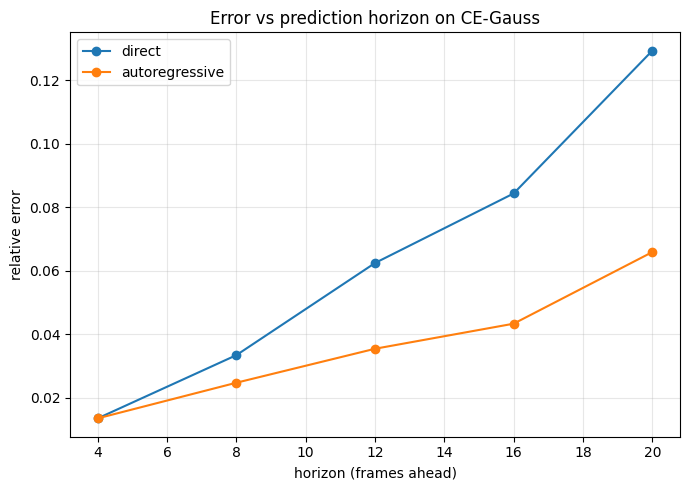

In [ ]:
#find the errors
horizons_direct, errors_direct = error_direct(model, device, final_time=20, n_steps=5)
horizons_auto, errors_auto = error_autoregressive(model, device, final_time=20, n_steps=5)

#make the plot of error vs horizon
plot_error_vs_horizon({"direct": (horizons_direct, errors_direct),"autoregressive": (horizons_auto, errors_auto)})
plt.show()

# 4. Spectral bias, and how it evolves

You may have noticed that Poseidon seems to fail to predict finer detail, as opposed to the more fundamental shapes. In this section we will focus on proving this via a power spectrum.

## 4.1 The radial energy spectrum

Take the 2D FFT of each velocity component on the $N\times N$ periodic grid. The kinetic energy carried each cell $(k_x, k_y)$ is

$$
\mathcal{E}(k_x,k_y) \;=\; |\hat u(k_x,k_y)|^2 + |\hat v(k_x,k_y)|^2 .
$$

Direction does not matter to us, only scale, so cells at a similar distance from the centre can be grouped together. Every cell whose distance rounds up to the same integer goes into ring $k$, which makes each ring an annulus one wavenumber wide. Averaging the energy over the cells of a ring gives

$$
E(k) \;=\; \frac{1}{|A_k|} \sum_{(k_x,k_y) \in A_k} \mathcal{E}(k_x,k_y),
\qquad A_k = \left\{ (k_x,k_y) : \left\lceil \sqrt{k_x^2+k_y^2} \,\right\rceil = k \right\}.
$$


Low $k$ means large, slowly varying structures and high $k$ means fine detail. A wavenumber $k$ corresponds to a wavelength of $N/k$ pixels, which is the useful way to read the axis: $k=8$ on a 128 grid is a 16-pixel feature.


In [ ]:
def radial_spectrum(field):
    """
    Derive the data necessary to plot a power spectrum

    ARGS:
        field (tensor): a field [4, H, W]. Only the two velocity channels are used

    RETURNS:
        avg_energy_per_distance (array): E(k), the mean kinetic energy in each annulus
        k (array): the integer wavenumber of each annulus
        k_max (float): the largest trustworthy k. Annuli past this poke outside the
                       grid and are undersampled
    """
    #pull the velocity channels out and convert to arrays (field is a tensor)
    x_velocity = field[1].numpy()
    y_velocity = field[2].numpy()

    #2D FFT of each component
    x_velocity_fft = np.fft.fft2(x_velocity)
    y_velocity_fft = np.fft.fft2(y_velocity)

    #kinetic energy at every point of the frequency grid
    kinetic_energy = np.abs(x_velocity_fft)**2 + np.abs(y_velocity_fft)**2

    #grid size, read off the field so this works at any resolution
    shape_x = x_velocity.shape[0]

    #normalised frequencies, scaled into integer wavenumbers in [-N/2, N/2)
    freqs_scaled = np.fft.fftfreq(shape_x) * shape_x

    #distance of every point from the origin of frequency space
    kx, ky = np.meshgrid(freqs_scaled, freqs_scaled, indexing="xy")
    k_radius = np.sqrt(kx**2 + ky**2)

    #beyond N/2 the annulus leaves the square, so it is undersampled
    k_max = shape_x / 2

    #round each radius up to an integer: these are the histogram bins
    k_int = np.ceil(k_radius).astype(int)

    #flatten and count the bins
    k_int_array = k_int.flatten()
    kinetic_energy_array = kinetic_energy.flatten()
    total_energy_per_distance = np.bincount(k_int_array, weights=kinetic_energy_array)
    bins_per_distance = np.bincount(k_int_array)

    #the average is the ratio
    avg_energy_per_distance = total_energy_per_distance / bins_per_distance

    #the wavenumber each bin corresponds to
    k = np.arange(len(avg_energy_per_distance))

    return avg_energy_per_distance, k, k_max

## 4.2 Truth against prediction, at one horizon

Investigate where on the power spectrum there is the most difference between the prediction and the truth.

## Task 4

Finish plot_radial_spectrum(). Mask values of k over k_max, and append the correct values to the spectra dictionary. 

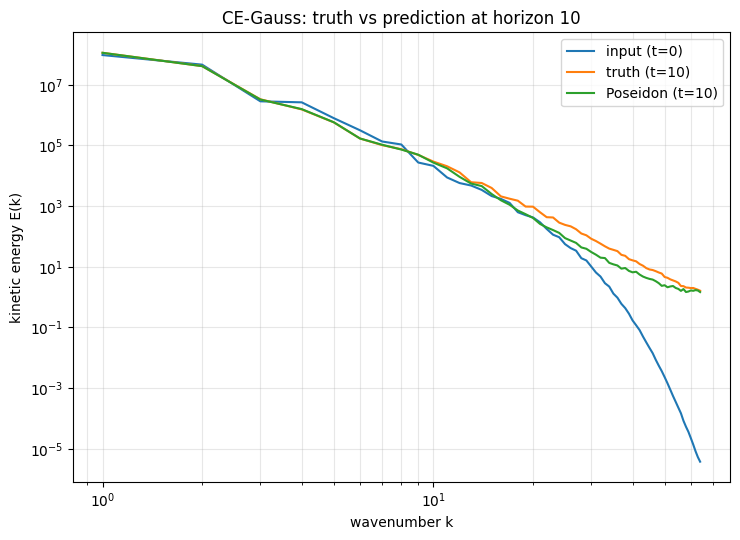

In [ ]:
def plot_radial_spectrum(fields):
    """
    Plot radial energy spectra on log-log axes.

    ARGS:
        fields (dict): {label: field}, each field a tensor [4, H, W], for example
                       {"truth": truth, "Poseidon-L": prediction}

    RETURNS:
        fig (Figure): the figure
        spectra (dict): {label: (k, E)} as actually plotted, already masked to the
                        trustworthy wavenumbers
    """
    fig = plt.figure(figsize=(7.5, 5.5))
    spectra = {}

    for label, field in fields.items():
        E, k, k_max = radial_spectrum(field)

        #----------

        #drop k=0 (the domain mean, not a scale) and everything past k_max
        mask = (k > 0) & (k <= k_max)
        plt.plot(k[mask], E[mask], label=label)
        spectra[label] = (k[mask], E[mask])

        #----------

    plt.yscale("log")
    plt.xscale("log")
    plt.xlabel("wavenumber k")
    plt.ylabel("kinetic energy E(k)")
    plt.title(f"{DATASET}: radial energy spectrum")
    plt.legend()
    plt.grid(True, which="both", alpha=0.3)
    plt.tight_layout()

    return fig, spectra


#get the 3 sets of data
input_field, truth, prediction, time = get_all_data(model, device, HORIZON)

#make the plot
fig, spectra_single = plot_radial_spectrum(
    {"input (t=0)": input_field,
     f"truth (t={HORIZON})": truth,
     f"Poseidon (t={HORIZON})": prediction})
plt.show()



## 4.3 How the bias evolves in time

Section 4.2 is a snapshot. The question that matters in practice is whether this divergence evolves over time.

Repeat 4.2 at four lead times, $t = 2, 10, 14, 20$, all of them direct predictions. Plot 4 curves, each representing a ratio

$$
R_T(k) \;=\; \frac{E_{\text{pred}}(k;\,T)}{E_{\text{truth}}(k;\,T)},
$$

for a given time horizon.

## Task 5

FInish writing spectrum_evolution(). You will need to use radial_spectrum() to fetch the necessary information, use masks to hide the irrelevant data and append the necessary data to the spectra dictionary.

## Question

How would you expect the ratio of Prediction/Truth to evolve over time?


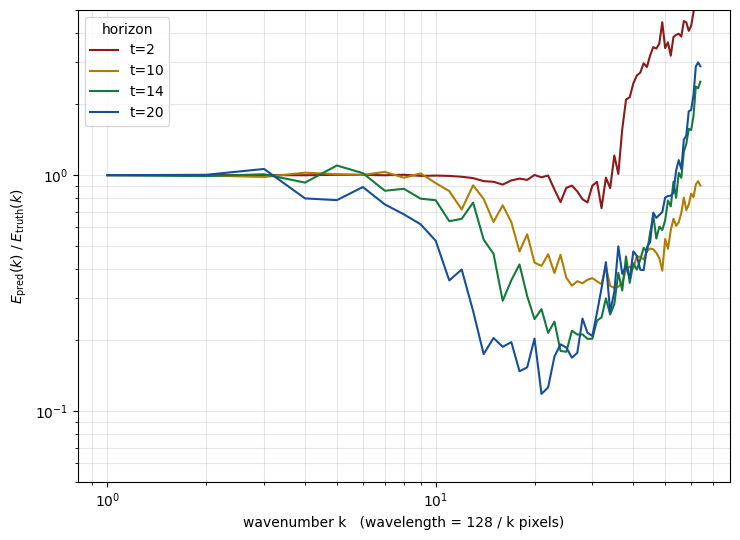

In [ ]:
def spectrum_evolution(model, device, horizons=(2, 10, 14, 20),
                       dataset_key=DATASET, index=0):
    """
    Per-wavenumber energy ratio between Poseidon and the truth, at several horizons.

    ARGS:
        model (ScOT): the loaded Poseidon-L model
        device (str): wherever the weights live
        horizons (tuple): the direct lead times to compare, in frames
        dataset_key (str): which entry of DATASETS to read
        index (int): which of the 240 held-out trajectories to use

    RETURNS:
        fig (Figure): the figure
        spectra (dict): {horizon: (k, E_truth, E_pred)}, already masked to the
                        trustworthy wavenumbers
    """
    fig = plt.figure(figsize=(7.5, 5.5))
    spectra = {}

    #one colour per horizon
    colours = ["#8b1a1a", "#b07d00", "#147a3c", "#154f9c"]

    #evaluate the corresponding E and k values at each horizon
    for position, horizon in enumerate(horizons):
        sample = get_sample(horizon, index=index, dataset_key=dataset_key)
        truth = sample["labels"]
        prediction = predict(model, sample, device)

        #----------
        E_truth, k, k_max = radial_spectrum(truth)
        E_pred, _, _ = radial_spectrum(prediction)

        
        #drop k=0 and everything past k_max
        mask = (k > 0) & (k <= k_max)
        k_m, E_t, E_p = k[mask], E_truth[mask], E_pred[mask]
        spectra[horizon] = (k_m, E_t, E_p)
        #----------

        #make the plot
        plt.plot(k_m, E_p / E_t, label=f"t={horizon}",
                 color=colours[position % len(colours)])
        
        

    #make the plot
    plt.xscale("log")
    plt.yscale("log")
    plt.ylim(0.05, 5)
    plt.xlabel("wavenumber k   (wavelength = 128 / k pixels)")
    plt.ylabel(r"$E_{\rm pred}(k)\;/\;E_{\rm truth}(k)$")
    plt.legend(title="horizon")
    plt.grid(True, which="both", alpha=0.3)
    plt.tight_layout()

    return fig, spectra


#run
fig, spectra = spectrum_evolution(model, device)
plt.show()

# 5. Out of distribution

Everything so far has been measured inside the training distribution. This section asks how accuracy falls off as the input drifts away from what Poseidon was trained on.

## 5.1 The spectral centroid

We want to first understand the concept of a spectral centroid. It is a singular number that a power spectrum on a grid can be collapsed to, with the formula

$$
\bar k \;=\; \frac{\sum_k k\, E(k)}{\sum_k E(k)}.
$$

A low $\bar k$ means the energy sits in large, smooth structures; a high $\bar k$ means more of it is in fine detail. What matters is the centroid at $t=0$, since that is the field Poseidon is given. It effectively encodes the initial frequency content which Poseidon will need to base its prediction on. 

We previously established that Poseidon fails to predict detail with higher frequency content. Therefore it may be reasonable to assume that Poseidon's error may grow as the spectroid value of the input field increases. Part of this investigation will focus on testing this assumption. 

### Task 6

Write out the spectral_centroid() function. Use radial_spectrum() to help, and remember to apply masks appropriately.


In [ ]:
def spectral_centroid(field):
    """
    The energy-weighted mean wavenumber of a field.

    ARGS:
        field (tensor): a field [4, H, W]. Only the two velocity channels are used

    RETURNS:
        centroid (float): the mean wavenumber, weighted by energy
    """
    #----------
    E, k, k_max = radial_spectrum(field)
    mask = (k <= k_max)

    return float((k[mask] * E[mask]).sum() / E[mask].sum())
    #----------

## 5.2 Testing Poseidon Across a Range of Spectroid Values

Here we will test the prediction's error at t=2 depends on the input spectroid value at t=0. 

## Question

How would you expect this graph to look? Do you think there will be any correlation between the spectroid value and Poseidon's errors?


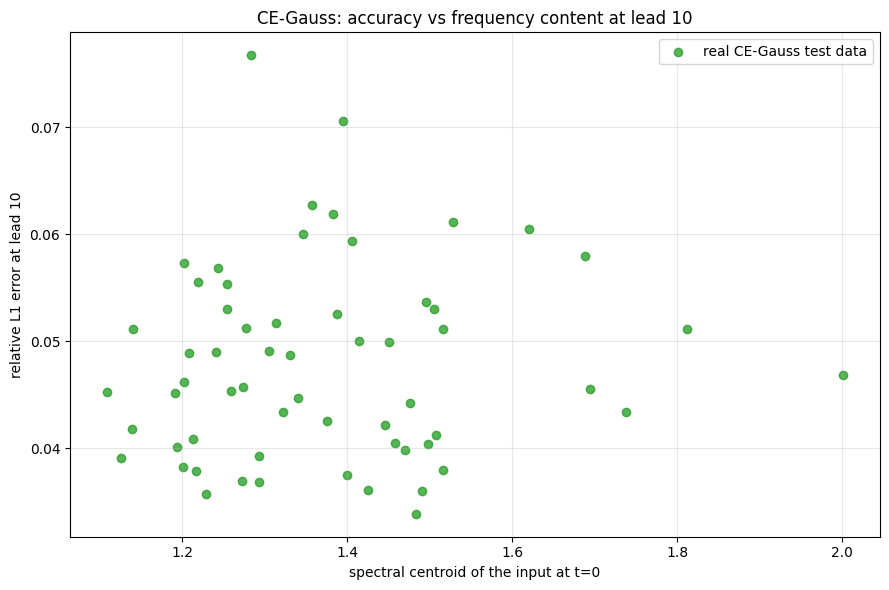

In [185]:
def plot_centroid_scatter(real=None, simulated=None):
    """
    Scatter relative error against the input's spectral centroid.

    ARGS:
        real (tuple): (centroids, errors) for the held-out test data, or None
        simulated (tuple): (centroids, errors) for the vortex flows, or None

    RETURNS:
        fig (Figure): the figure
        ax (Axes): its axes, so the caller can shade the real data's range
    """
    fig, ax = plt.subplots(figsize=(9, 6))

    #the real points go on FIRST so the simulated ones draw over them
    if real is not None:
        ax.scatter(real[0], real[1], color="#2ca02c", alpha=0.8,
                   label="real CE-Gauss test data")

    if simulated is not None:
        ax.scatter(simulated[0], simulated[1], color="#c00000", alpha=0.8,
                   label="simulated (vortices)")

    #the two clouds sit an order of magnitude apart, so a linear axis would
    #flatten the smaller one onto zero
    ax.set_yscale("log")

    ax.set_xlabel("spectral centroid of the input at t=0")
    ax.set_ylabel(f"relative L1 error at lead {HORIZON}")
    ax.grid(alpha=0.3, which="both")
    ax.legend()
    fig.tight_layout()

    return fig, ax


def accuracy_vs_frequency(model, device, horizon=HORIZON, dataset_key=DATASET,
                          n_samples=60):
    """
    One point per held-out trajectory: input centroid against prediction error.

    ARGS:
        model (ScOT): the loaded Poseidon-L model
        device (str): wherever the weights live
        horizon (int): how many frames ahead to predict, at most 20
        dataset_key (str): which entry of DATASETS to read
        n_samples (int): how many of the 240 held-out trajectories to use

    RETURNS:
        fig (Figure): the figure
        centroids (array): the spectral centroid of each input
        errors (array): the relative L1 error of the forecast for each one
    """
    #set up the arrays
    centroids, errors = [], []

    #stride through the 240 held-out trajectories rather than taking every one,
    #purely so the cell finishes in seconds
    n_trajectories = len(load_window(horizon, dataset_key))
    indices = np.linspace(0, n_trajectories - 1, n_samples).astype(int)

    for index in indices:

        #the input, the truth and the prediction for this trajectory
        sample = get_sample(horizon, index=int(index), dataset_key=dataset_key)
        input_field = sample["pixel_values"]
        truth = sample["labels"]
        prediction = predict(model, sample, device)

        #append the frequency content of the input and the error of the forecast
        centroids.append(spectral_centroid(input_field))
        errors.append(relative_error(truth, prediction).item())

    #arrays rather than lists, because 5.7 does arithmetic on them
    centroids, errors = np.array(centroids), np.array(errors)

    #hand the one series over to the shared plotting function
    fig, _ = plot_centroid_scatter(real=(centroids, errors))

    return fig, centroids, errors


#plot the graph
fig, real_centroids, real_errors = accuracy_vs_frequency(model, device, horizon=HORIZON)
plt.show()



## 5.3 Setting Up The Simulation Physics

In order to test how Poseidon performs outside of the training distribution, we have to make our own simulations to feed into it. The section below will focus on making the Physics of our simulations work. 



In [186]:
#import functions from a simulation generator script. ROOT is already on
#sys.path from 1.1, and finitevolume_python sits inside it
from finitevolume_python.finitevolume import (
    getConserved, getPrimitive, getGradient,
    extrapolateInSpaceToFace, applyFluxes, getFlux,
)

#establish the size of the grid and the hop in time per frame
N_GRID = 128         
DT_PER_LEAD = 0.05    


#quickly define speed of sound
def speed_of_sound(pressure, gamma, rho):
    """
    Speed of sound in an ideal gas.

    ARGS:
        pressure (array): the pressure at each grid point [N, N]
        gamma (float): the adiabatic index
        rho (array): the density at each grid point [N, N]

    RETURNS:
        c (array): the local speed of sound [N, N]
    """
    return np.sqrt(gamma * pressure / rho)


def simulation_logic(rho, vx, vy, P, gamma, snapshot_times, N=N_GRID,
                     courant_number=0.4):
    """
    Integrate the compressible Euler equations and return the requested snapshots.

    ARGS:
        rho (array): the initial density at each grid point [N, N]
        vx (array): the initial x-velocity [N, N]
        vy (array): the initial y-velocity [N, N]
        P (array): the initial pressure [N, N]
        gamma (float): the adiabatic index
        snapshot_times (list): the times to record, in solver time units
        N (int): the grid size along each side
        courant_number (float): the CFL number, capping how far a wave may travel
                                in one step so the solver stays stable

    RETURNS:
        field (array): [len(snapshot_times), 4, N, N] holding rho, vx, vy, P at
                       each requested time
    """
    #convention used by Poseidon and PDEBench: the box has side length 1
    box_side_length = 1

    #from that, the cell width and cell volume
    dx = box_side_length / N
    vol = dx**2

    #convert primitive variables into the conserved ones the solver advances
    Mass, Momx, Momy, Energy = getConserved(rho, vx, vy, P, gamma, vol)

    #the output array, one slot per requested snapshot
    field = np.zeros((len(snapshot_times), 4, N, N), dtype=np.float32)

    time_targets = list(snapshot_times)
    snapshot_index = 0
    t = 0

    #capture t=0 directly. consequent snapshots are built on top of this
    while time_targets[snapshot_index] == 0:
        field[snapshot_index] = np.stack([rho, vx, vy, P])
        snapshot_index += 1

    while snapshot_index < len(time_targets):

        #recover the primitive variables from the conserved ones
        rho, vx, vy, P = getPrimitive(Mass, Momx, Momy, Energy, gamma, vol)
        velocity_abs = np.sqrt(vx**2 + vy**2)

        #CFL condition: no wave may cross a cell in one step
        dt = courant_number * np.min(
            dx / (velocity_abs + speed_of_sound(P, gamma, rho)))

        #if this step would overshoot the next snapshot, shorten it to land exactly
        land_on_target = False
        if t + dt >= time_targets[snapshot_index]:
            dt = time_targets[snapshot_index] - t
            land_on_target = True

        #gradients of the four primitive variables
        rho_dx, rho_dy = getGradient(rho, dx)
        vx_dx, vx_dy = getGradient(vx, dx)
        vy_dx, vy_dy = getGradient(vy, dx)
        P_dx, P_dy = getGradient(P, dx)

        #half step in time (the "Hancock" predictor)
        rho_prime = rho - 0.5 * dt * (vx * rho_dx + rho * vx_dx
                                      + vy * rho_dy + rho * vy_dy)
        vx_prime = vx - 0.5 * dt * (vx * vx_dx + vy * vx_dy + (1 / rho) * P_dx)
        vy_prime = vy - 0.5 * dt * (vx * vy_dx + vy * vy_dy + (1 / rho) * P_dy)
        P_prime = P - 0.5 * dt * (gamma * P * (vx_dx + vy_dy) + vx * P_dx + vy * P_dy)

        #extrapolate to the cell faces
        rho_XL, rho_XR, rho_YL, rho_YR = extrapolateInSpaceToFace(rho_prime, rho_dx, rho_dy, dx)
        vx_XL, vx_XR, vx_YL, vx_YR = extrapolateInSpaceToFace(vx_prime, vx_dx, vx_dy, dx)
        vy_XL, vy_XR, vy_YL, vy_YR = extrapolateInSpaceToFace(vy_prime, vy_dx, vy_dy, dx)
        P_XL, P_XR, P_YL, P_YR = extrapolateInSpaceToFace(P_prime, P_dx, P_dy, dx)

        #Rusanov (local Lax-Friedrichs) fluxes through each face
        flux_Mass_X, flux_Momx_X, flux_Momy_X, flux_Energy_X = getFlux(
            rho_XL, rho_XR, vx_XL, vx_XR, vy_XL, vy_XR, P_XL, P_XR, gamma)
        flux_Mass_Y, flux_Momy_Y, flux_Momx_Y, flux_Energy_Y = getFlux(
            rho_YL, rho_YR, vy_YL, vy_YR, vx_YL, vx_YR, P_YL, P_YR, gamma)

        #apply them
        Mass = applyFluxes(Mass, flux_Mass_X, flux_Mass_Y, dx, dt)
        Momx = applyFluxes(Momx, flux_Momx_X, flux_Momx_Y, dx, dt)
        Momy = applyFluxes(Momy, flux_Momy_X, flux_Momy_Y, dx, dt)
        Energy = applyFluxes(Energy, flux_Energy_X, flux_Energy_Y, dx, dt)

        t += dt

        #we landed exactly on a requested time, so record it
        if land_on_target == True:
            rho, vx, vy, P = getPrimitive(Mass, Momx, Momy, Energy, gamma, vol)   
            field[snapshot_index] = np.stack([rho, vx, vy, P]).astype(np.float32)
            snapshot_index += 1

    return field

## 5.4 The initial condition

Now that we established the underlying Physics that our simulation will obey, we need to create an 'initial condition'. This is a field that will be fed both into our simulation and into Poseidon so that both of them can make their respective predictions.

We will do this by simulating vortices. The initial conditions of *CE-Gauss* require that there is equal pressure in the initial field, with only velocity being varied. This implies that at t=0 we want there to be a divergence of 0 in every part of the grid - otherwise there would be a pressure imbalance. 

## Task 7

Finish vortices_initial_condition(). You want to make a for loop that, for every item spins, makes a vortex with random center coordinates, a given radius, and a given spin. You then want to append all the vortices you made to one grid.

In [ ]:
#initial conditions of the CE-Gauss Dataset
RHO = 1.0
P = 2.5
GAMMA = 1.4

#one more initial condition. this ensures the energy content in the simulation and what poseidon is used to are reasonably similar
frames = [denormalise(load_window(2)[i]["pixel_values"]) for i in range(20)]
SPEED_RMS = float(np.mean([float(torch.sqrt((frame[1]**2 + frame[2]**2).mean())) for frame in frames]))

#number of simulated vorteces
N_VORTICES = 60     
                    


def single_vortex(cx, cy, radius, spin, box=N_GRID):
    """
    The velocity field of one vortex, on a periodic grid.

    ARGS:
        cx (float): the vortex centre's x coordinate, in pixels
        cy (float): the vortex centre's y coordinate, in pixels
        radius (float): the vortex radius, in pixels
        spin (float): +1 or -1, which way the vortex turns
        box (int): the grid size along each side

    RETURNS:
        vx (array): the x-velocity this vortex contributes at each point [box, box]
        vy (array): the y-velocity this vortex contributes at each point [box, box]
    """
    #the problem with Poseidon is that a wave travelling into one end will come out the other
    #this makes distance calculations more complex than they need to be: hence below

    #create an index
    y, x = np.indices((box, box))

    #make a box of zeros
    vx = np.zeros((box, box))
    vy = np.zeros((box, box))

    #iterate through x and y coordinates
    for ix in (-1, 0, 1):
        for iy in (-1, 0, 1):

            #find the distance from the center of the vortex
            dx = x - (cx + ix * box)          
            dy = y - (cy + iy * box)

            #vortices will be based on exponential decay
            strength = spin * np.exp(
                -(dx**2 + dy**2) / (2 * radius**2))
            vx += -dy * strength                  
            vy += dx * strength

    return vx, vy



def vortices_initial_condition(radius, rho, pressure, n_vortices=N_VORTICES, speed_rms=None, box=N_GRID):
    """
    Build a CE-Gauss-like initial condition out of many random vortices.

    ARGS:
        radius (float): the vortex radius, in pixels. This is the knob section 5
                        sweeps, since it sets how fine-grained the flow is
        rho (float): the uniform background density
        pressure (float): the uniform background pressure
        n_vortices (int): how many vortices to add up
        speed_rms (float): the target RMS speed, or None to match the real data
        box (int): the grid size along each side

    RETURNS:
        initial (array): the initial condition [4, box, box] as rho, vx, vy, p, in
                         the notebook's [channel, y, x] frame
    """

    #establish randomness
    rng = np.random.default_rng()

    #half spinning each way, so the net circulation is exactly zero
    spins = np.array([1.0] * (n_vortices // 2) + [-1.0] * (n_vortices - n_vortices // 2))
    rng.shuffle(spins)

    #-------
    #make a grid with no vortices
    vx = np.zeros((box, box))
    vy = np.zeros((box, box))

    #create vorteces for different spin values
    for spin in spins:
        cx, cy = rng.uniform(0, box, 2)
        a, b = single_vortex(cx, cy, radius, spin, box)
        vx += a
        vy += b
    #------

    #normalise the RMS of the vortices to match that of Poseidon
    #while we want to vary the frequency content, we want to give Poseidon a simulation with energy content it is
    #more familiar with
    if speed_rms is None:
        speed_rms = SPEED_RMS
    scale = np.sqrt((vx**2 + vy**2).mean())
    vx = vx / scale * speed_rms
    vy = vy / scale * speed_rms

    #return the full initial condition. rho, velocities, and pressure - each as a grid, and all stacked into one shape
    return np.stack([np.full((box, box), rho), vx, vy, np.full((box, box), pressure)])

## 5.5 Make One Forward Pass

This is a very important function. For a given radius of a vortex it:

1. builds the initial condition
2. propagates the simulation to a given time
3. makes Poseidon do a direct prediction of a give time
4. compares the simulation(truth) against Poseidon

Note that this function has an optional argument 'lead=Horizon'. You may change this to any hard coded value you would like. 

In [ ]:
def simulate_forward_pass(model, device, radius, n_vortices=N_VORTICES,
                  speed_rms=None, lead=HORIZON):
    """
    Vortex initial condition -> simulation forward pass -> one Poseidon forward pass.

    ARGS:
        model (ScOT): the loaded Poseidon-L model
        device (str): wherever the weights live
        radius (float): the vortex radius, in pixels
        n_vortices (int): how many vortices to build the initial condition from
        speed_rms (float): the target RMS speed, or None to match the real data
        lead (int): how many frames ahead to predict

    RETURNS:
        simulation_input_field (tensor): the flow at t=0, in model units [4, H, W]
        simulation_prediction (tensor): the solver's answer at t=lead [4, H, W]
        poseidon_prediction (tensor): Poseidon's forecast for the same [4, H, W]
        error (float): the relative L1 error between the two forecasts
    """
    #build the initial condition, [4, y, x] in the notebook's own frame.
    initial = vortices_initial_condition(radius, RHO, P, n_vortices=n_vortices, speed_rms=speed_rms)

    #the simulation works in [x, y], but Poseidon stores its velocity values in 
    #an array [y, x]. Therefore a transpose is necessary for them to match. 
    initial_T = initial.transpose(0, 2, 1)

    #make the snapshots. The * unpacks the [4, x, y] array into the four
    #separate channel arrays the solver takes: rho, vx, vy, P
    snapshots = simulation_logic(*initial_T, GAMMA, [0.0, DT_PER_LEAD * lead], N=N_GRID)

    #get the simulation prediction and input field
    #normalise both of them so they can be loaded into Poseidon
    simulation_input_field = normalise(snapshots[0].transpose(0, 2, 1))
    simulation_prediction = normalise(snapshots[1].transpose(0, 2, 1))

    #make Poseidon do one forward pass and make a prediction
    poseidon_prediction = predict(model, {"pixel_values": simulation_input_field,
                                          "time": lead / TIME_NORM}, device)

    #how far Poseidon lands from the solver's answer
    error = float(relative_error(simulation_prediction, poseidon_prediction))

    #return the 4 fields
    return (simulation_input_field, simulation_prediction, poseidon_prediction, error)

## 5.6 Vary The Complexity of the Simulation

See how Poseidon performs when you vary the radius of the simulated vortices (smaller radius implies finer detail).

## Task 8

Finish writing simulation_field_panel. You want it to plot 4 figures for every radius you feed into it, so use truth_vs_prediction(). Use simulate_forward_pass() to get the relevant data. Remember simulate_forward_pass() has the option argument 'lead' that allows you to change how many frames into the future you want to make a prediction and comparison.

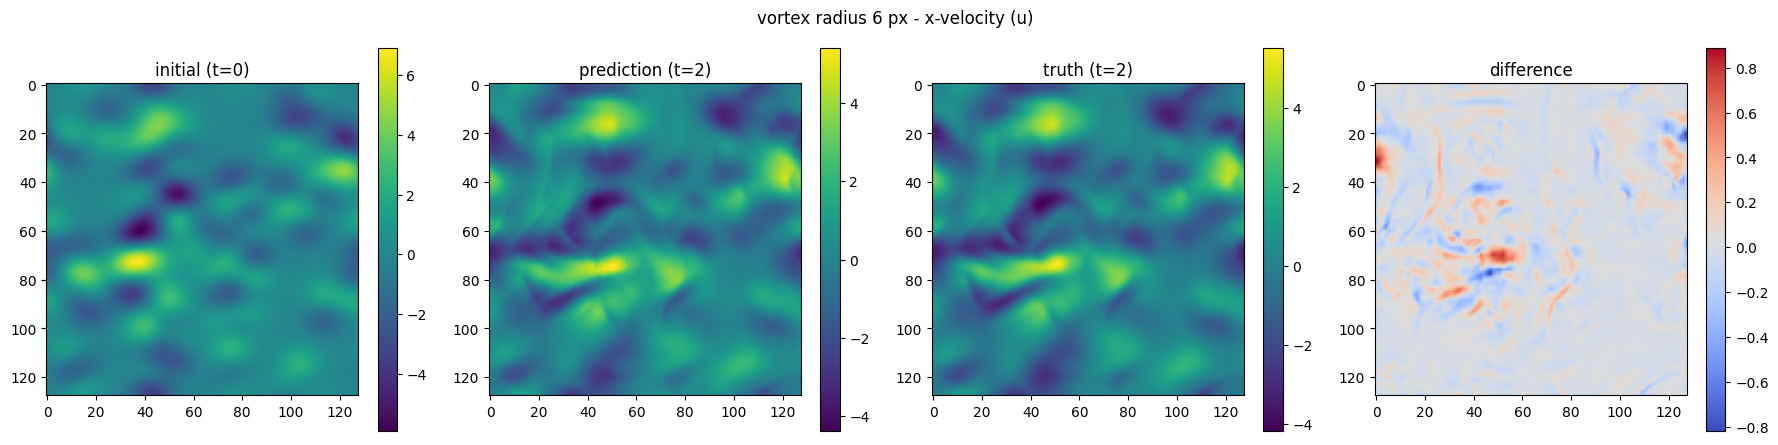

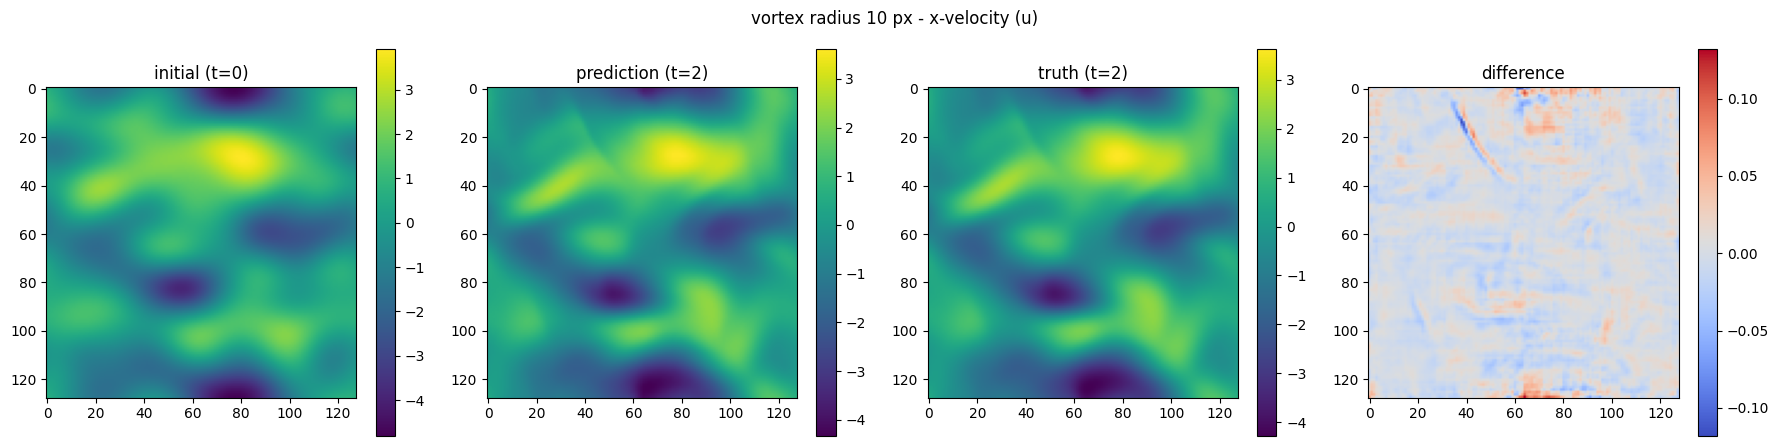

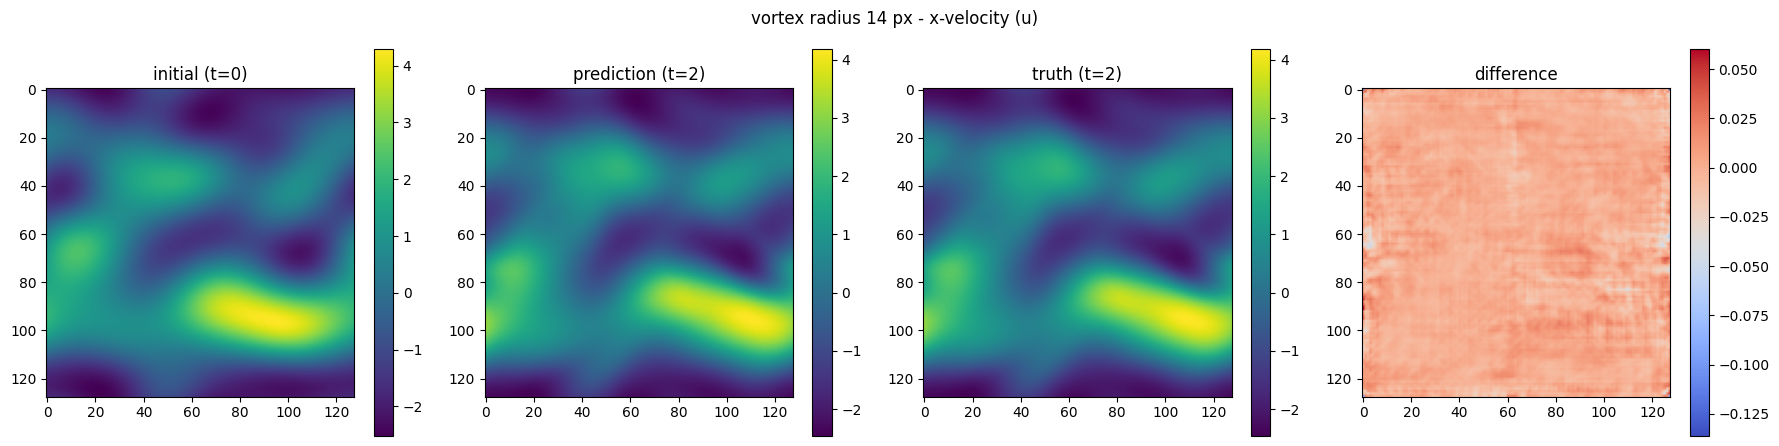

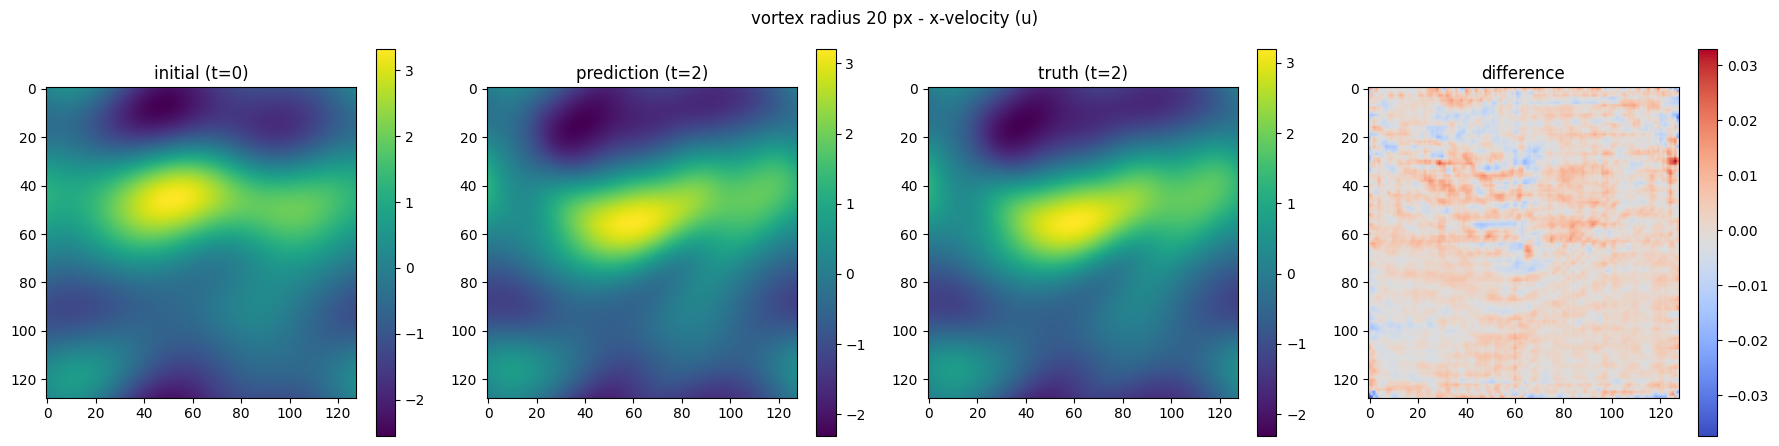

In [ ]:
def simulation_field_panel(model, device, radii, channel=1):
    """
    One four-panel figure per vortex radius.

    ARGS:
        model (ScOT): the loaded Poseidon-L model
        device (str): wherever the weights live
        radii (list): the vortex radii in pixels, one figure each
        channel (int): which of the four channels to draw
    """
    #-----
    for radius in radii:

        #the solver's own answer is the truth Poseidon is compared against
        simulation_input, solver_answer, poseidon_prediction, _ = simulate_forward_pass(model, device, radius)

        fig = truth_vs_prediction(simulation_input, solver_answer, poseidon_prediction, HORIZON, channel=channel)
        fig.suptitle(f"vortex radius {radius} px - {CHANNEL_NAMES[channel]}")
        plt.show()
    #----


simulation_field_panel(model, device, radii=[6, 10, 14, 20])

## 5.7 The measurement

This is the most important task in the notebook. By varying the radii of the vortices we can vary the level of detail we introduce to the input field. Smaller radii = finer detail. This is why we have error_vs_centroid() - a single function that both performs the necessary calculations and plots the graphs. 

The radii come from two draws: one over the full range, and a second over the sub-range that lands inside the real data's centroid band. The second draw is purely for legibility, since error varies a lot between flows of the same centroid so we want more points within that range to make a more accurate comparison. 

## Task 9

Finish error_vs_centroid(). You need to code a for loop that goes through every radius in 'radii', performs a forward pass, fetches the input field and the error, and appends them to the appropriate arrays. 

Note that it will take a while for this section to run (~5 mins).


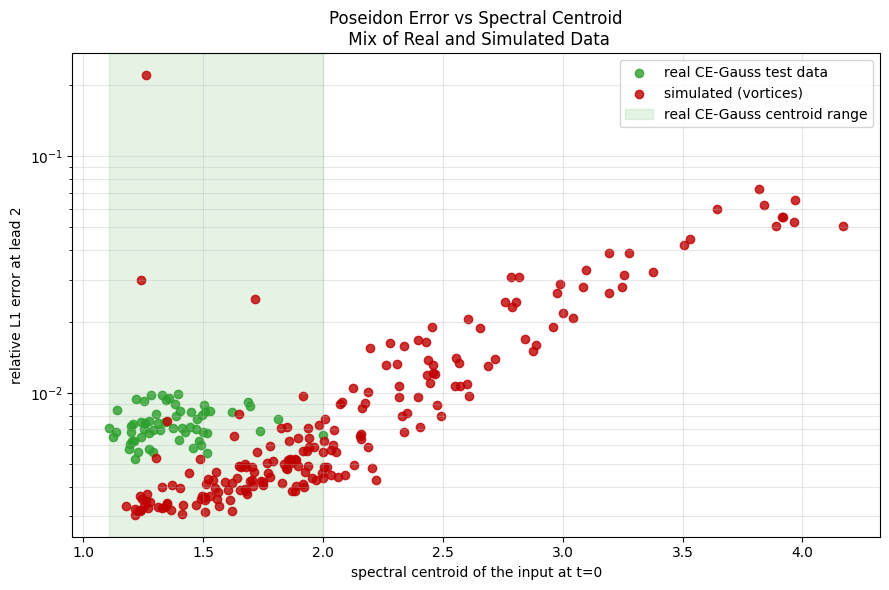

In [ ]:
def error_vs_centroid(model, device, n_points=120, radius_range=(6, 20),
                      n_band=80, band_radius_range=(12, 20),
                      n_vortices=N_VORTICES,
                      real_data =None):
    """
    Sweep the vortex radius and plot error against input spectral centroid.

    ARGS:
        model (ScOT): the loaded Poseidon-L model
        device (str): wherever the weights live
        n_points (int): how many radii to draw across the full range
        radius_range (tuple): the (low, high) radius bounds for that full draw
        n_band (int): how many extra radii to draw inside the real data's band
        band_radius_range (tuple): the (low, high) bounds for that second draw
        n_vortices (int): how many vortices per initial condition
        real_data (tuple): (centroids, errors) from accuracy_vs_frequency, or None
                           to draw the simulated points alone

    RETURNS:
        fig (Figure): the figure
        centroids (array): the spectral centroid of each simulated input
        errors (array): the relative L1 error for each one
    """
    #the radii, and the vortex positions behind them, are drawn fresh on every run
    rng = np.random.default_rng()

    #we want a broad range of spectroid values in our initial condition to see how Poseidon performs
    #however, we want more data points within the spectroid range that Poseidon was trained on
    #this is purely for visual interpretation - error varies a lot even for fields with the same spectroid values
    #thus we introduce more points to the lower spectroid range to make the comparison more visually obvious

    #whole range of spectroid values
    radius_low, radius_high = radius_range
    sweep_radii = rng.uniform(radius_low, radius_high, n_points)

    #range of spectroid values concentrated around what Poseidon was trained on
    band_low, band_high = band_radius_range
    band_radii = rng.uniform(band_low, band_high, n_band)

    #concatenate the two sets of values into one
    radii = np.concatenate([sweep_radii, band_radii])

    #prepare data collection
    centroids, errors = [], []

    #-------
    #fetch the simulation input field and the error. These are the only things needed for the centroid
    for radius in radii:
        simulation_input_field, _, _, error = simulate_forward_pass(model, device, float(radius), n_vortices)

        #the centroid is a property of the input
        #append the data
        centroids.append(spectral_centroid(simulation_input_field))
        errors.append(error)
    #------

    centroids, errors = np.array(centroids), np.array(errors)

    #make the plot
    fig, ax = plot_centroid_scatter(real=real_data, simulated=(centroids, errors))

    #shade the centroid range the real data covers. zorder puts it behind the
    #points, and the legend is rebuilt so the band gets an entry
    if real_data is not None:
        ax.axvspan(real_data[0].min(), real_data[0].max(), color="#2ca02c",
                   alpha=0.12, zorder=0, label="real CE-Gauss centroid range")
        ax.legend()

    return fig, centroids, errors


#plot
fig, sim_centroids, sim_errors = error_vs_centroid(model, device,
                        real_data=(real_centroids, real_errors))
plt.show()

# 6. Resolution invariance

A neural operator is supposed to learn a map between function spaces, not between arrays. If that is true, the same weights should act on the same underlying function sampled on any grid.

Poseidon can be evaluated at resolutions other than $128^2$ because its internal operations SHOULD BE resolution-agnostic. We will be testing if this is true.

## 6.1 $128^2$ against $64^2$

Same trajectory at same horizon, varying only the input resolution. The 'resize' function was made in a way that it actually throws away data as opposed to performing interpolation.

## Question

Given what is said above, how do you expect Poseidon to perform at lower resolutions? 

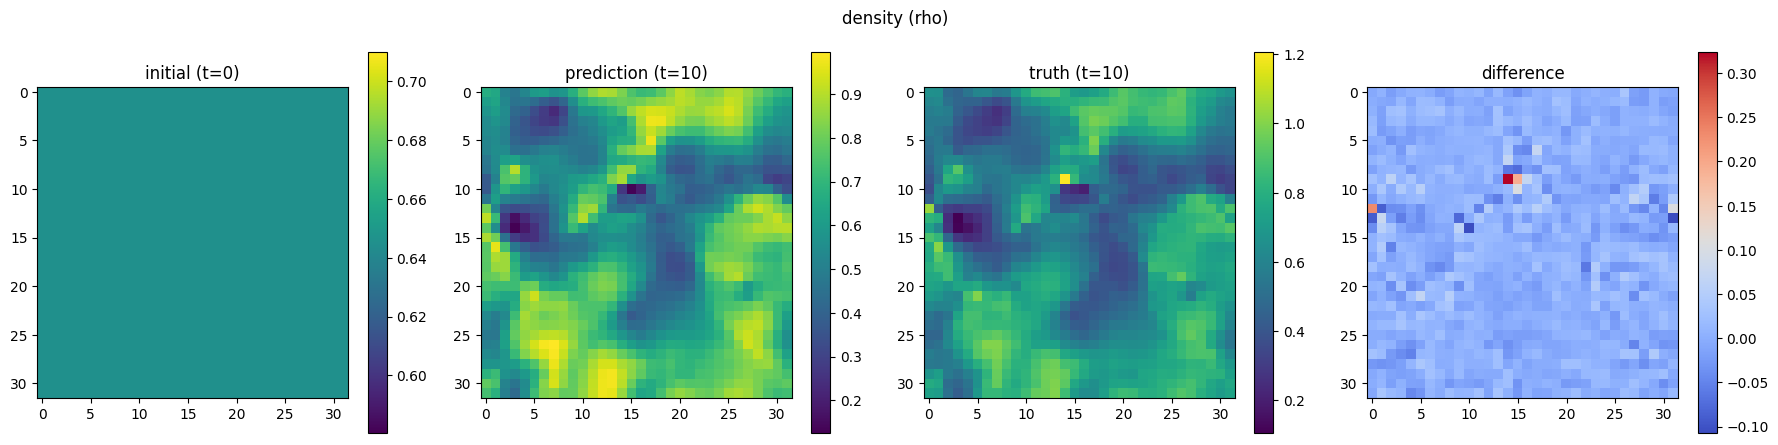

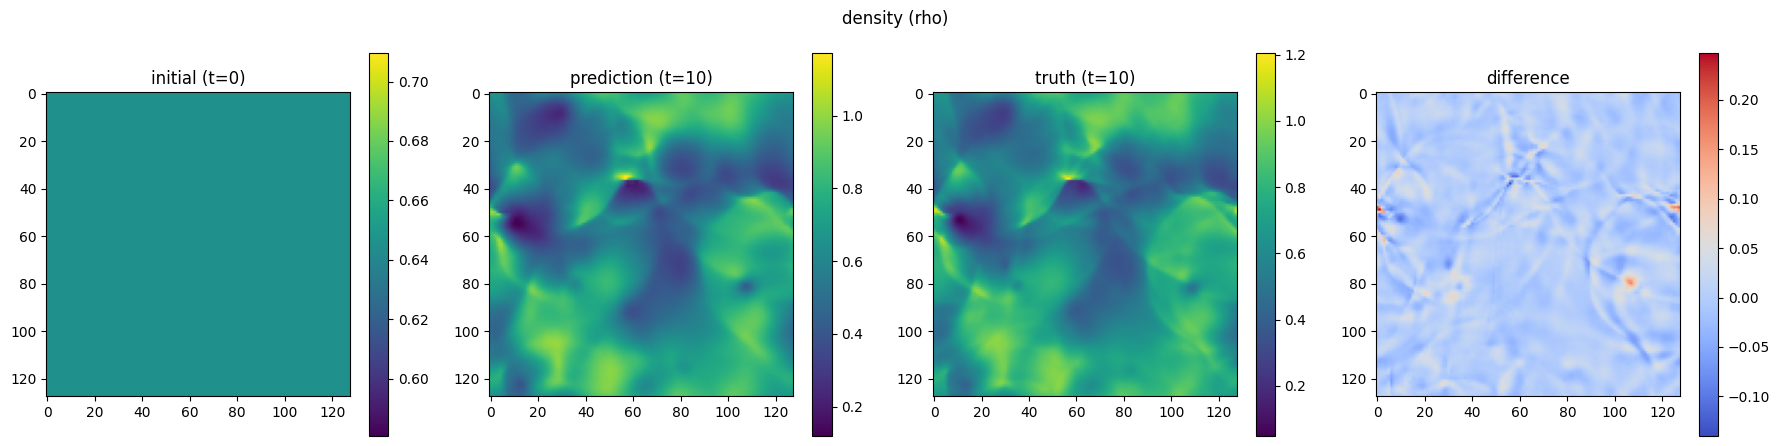

In [ ]:

def resize(field, scale):
    """
    Downsample a field by keeping every scale-th pixel along both spatial axes.

    ARGS:
        field (tensor): a field [4, H, W]
        scale (int): the stride. scale=2 turns 128x128 into 64x64

    RETURNS:
        new_field (tensor): the coarsened field [4, H // scale, W // scale]
    """

    #field is [channels, H, W]. Resize only the spatial axes, but keep every channel
    #if scale=2 then 128x128 --> 64x64 and the rest of the data is deleted
    new_field = field[:, ::scale, ::scale]

    return new_field

def resize_truth_vs_prediction(model, device, field, true_field, horizon,
                               scale, channel=0):
    """
    Resize an input and its truth, then draw the four-panel comparison.

    ARGS:
        model (ScOT): the loaded Poseidon-L model
        device (str): where the model normally lives, to move it back afterwards
        field (tensor): the input at t=0, at full resolution [4, H, W]
        true_field (tensor): the true field at the horizon [4, H, W]
        horizon (int): how many frames ahead to predict, at most 20
        scale (int): the downsampling stride passed to resize()
        channel (int): which of the four channels to draw

    RETURNS:
        fig (Figure): the four-panel figure at the coarsened resolution
    """

    #resize the input field and the truth by the given factor
    resized_field = resize(field, scale)
    resized_true_field = resize(true_field, scale)

    #MPS can't run the model's internal FFT-based resize at a non-128 resolution
    #Complex dtype unsupported on this backend, so force CPU for this call only
    model_cpu = model.to("cpu")
    prediction = predict(model_cpu, {"pixel_values": resized_field,
                                     "time": horizon / TIME_NORM}, "cpu")

    fig = truth_vs_prediction(resized_field, resized_true_field, prediction,
                              horizon, channel=channel)

    #put the model back where it was
    model.to(device)

    return fig


#make a plot of truth, prediction and difference for the resized field
resize_truth_vs_prediction(model, device, input_field, truth, HORIZON, scale=4, channel=0)
plt.show()

resize_truth_vs_prediction(model, device, input_field, truth, HORIZON, scale=2, channel=0)
plt.show()